#  Data Preprocessing in Machine Learning

Author: Varun Singh

## Objective
Learn how to prepare raw data before training a Machine Learning model.

## What is Data Preprocessing?

Data Preprocessing is the process of cleaning and transforming raw data into a format that is suitable for Machine Learning algorithms.

### Steps:
- Import Libraries
- Load Dataset
- Explore Dataset
- Handle Missing Values
- Encode Categorical Data
- Feature Scaling
- Split Dataset

In [2]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries Imported Successfully ")

Libraries Imported Successfully 


## Load Dataset

In [3]:
df = pd.read_csv("/content/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Check Dataset Shape

In [4]:
df.shape

(891, 12)

## Check Columns

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Statistics

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Missing Values

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Fill Missing Values

In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Cabin"] = df["Cabin"].fillna("Unknown")

## Verify

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Encode Categorical Data

In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])

## Check Dataset

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,2


## Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Age","Fare"]] = scaler.fit_transform(df[["Age","Fare"]])

## Features & Target

In [15]:
X = df[["Pclass","Sex","Age","Fare"]]

y = df["Survived"]

## Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data")

print(X_train)

print("Testing Data")

print(X_test)

Training Data
     Pclass  Sex       Age      Fare
331       1    1  1.240235 -0.074583
733       2    1 -0.488887 -0.386671
382       3    1  0.202762 -0.488854
704       3    1 -0.258337 -0.490280
813       3    0 -1.795334 -0.018709
..      ...  ...       ...       ...
106       3    0 -0.642586 -0.494391
270       1    1 -0.104637 -0.024246
860       3    1  0.894411 -0.364355
435       1    0 -1.180535  1.767741
102       1    1 -0.642586  0.907738

[712 rows x 4 columns]
Testing Data
     Pclass  Sex       Age      Fare
709       3    1 -0.104637 -0.341452
439       2    1  0.125912 -0.437007
840       3    1 -0.719436 -0.488854
720       2    0 -1.795334  0.016023
39        3    0 -1.180535 -0.422074
..      ...  ...       ...       ...
433       3    1 -0.949986 -0.504962
773       3    1 -0.104637 -0.502949
25        3    0  0.663861 -0.016444
84        2    0 -0.949986 -0.437007
10        3    0 -1.949034 -0.312172

[179 rows x 4 columns]


## Check Shape

In [17]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (712, 4)
Testing Shape: (179, 4)


## Final Dataset

In [18]:
X_train.head()

,Pclass,Sex,Age,Fare
331,1,1,1.240235,-0.074583
733,2,1,-0.488887,-0.386671
382,3,1,0.202762,-0.488854
704,3,1,-0.258337,-0.490280
813,3,0,-1.795334,-0.018709


## Age Distribution

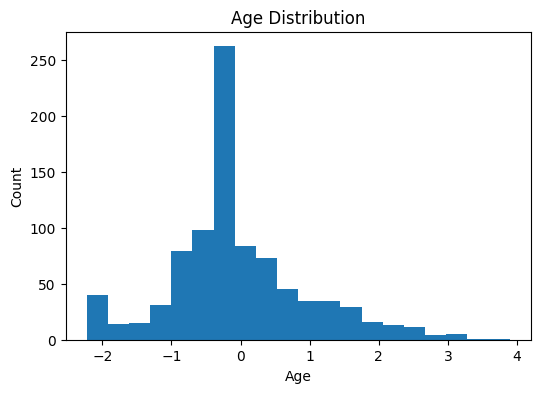

In [20]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Gender Count

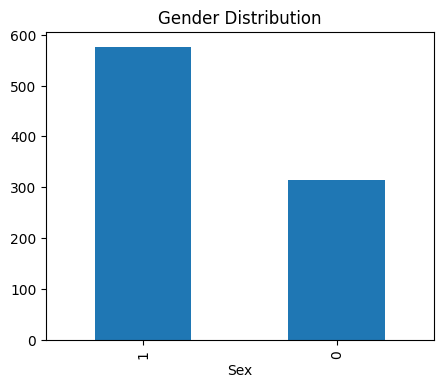

In [21]:
plt.figure(figsize=(5,4))
df["Sex"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

## Fare Distribution

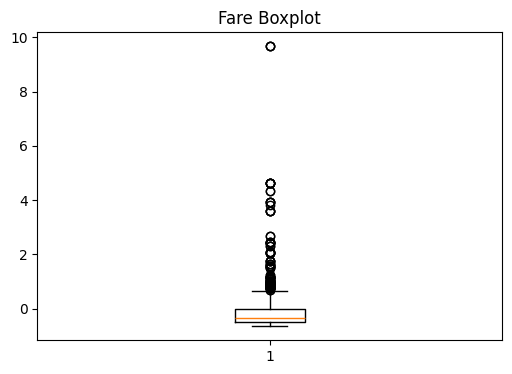

In [22]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Fare"])
plt.title("Fare Boxplot")
plt.show()

# ✅ Key Learnings

- Imported Titanic dataset
- Explored dataset
- Identified missing values
- Handled missing values
- Encoded categorical variables
- Applied feature scaling
- Split dataset into training and testing sets

The data is now ready for Machine Learning models.